First, we import the necessary libraries and load your wine dataset.

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

Load the dataset

In [108]:
df = pd.read_csv('wine-quality-white-and-red (1).csv')

Initial check

In [109]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6497, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Check for missing values

In [110]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Encode categorical 'type' column (Red=0, White=1)

In [111]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

Select features for clustering

In [112]:
features = df.drop(['type'], axis=1)

Feature Scaling

In [113]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

print("\nData preprocessing complete. Features scaled.")


Data preprocessing complete. Features scaled.


In [114]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,1,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,1,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,1,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Correlation Heatmap

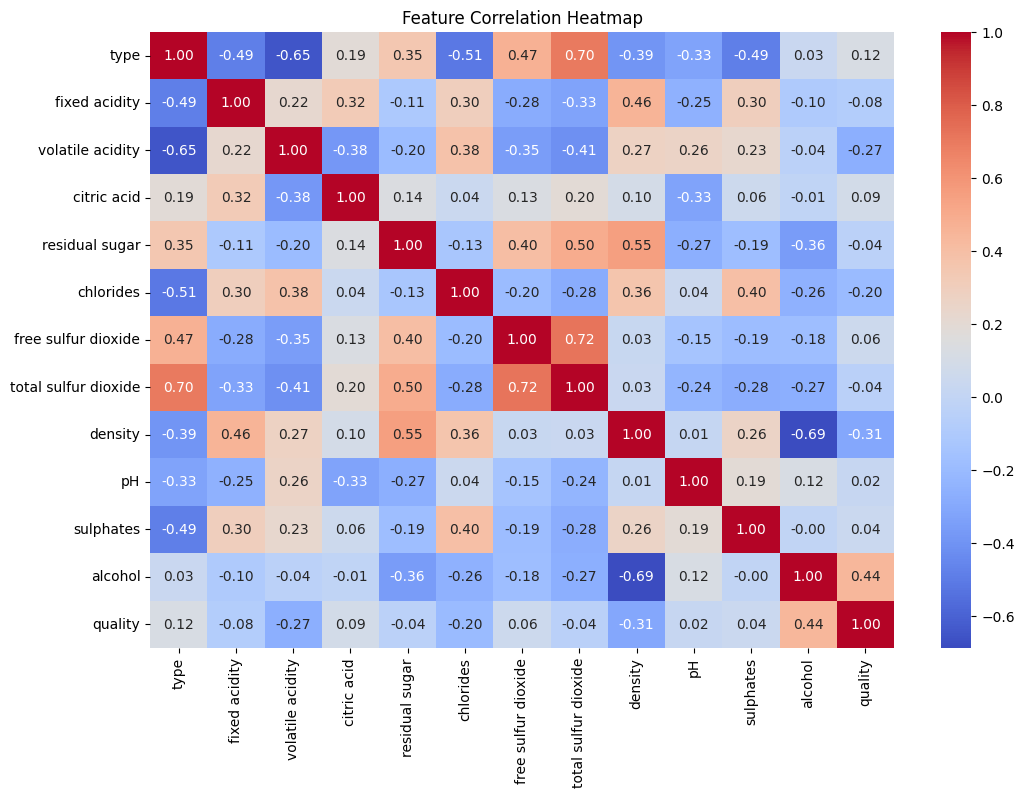

In [115]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

Finding the Optimal Number of Clusters

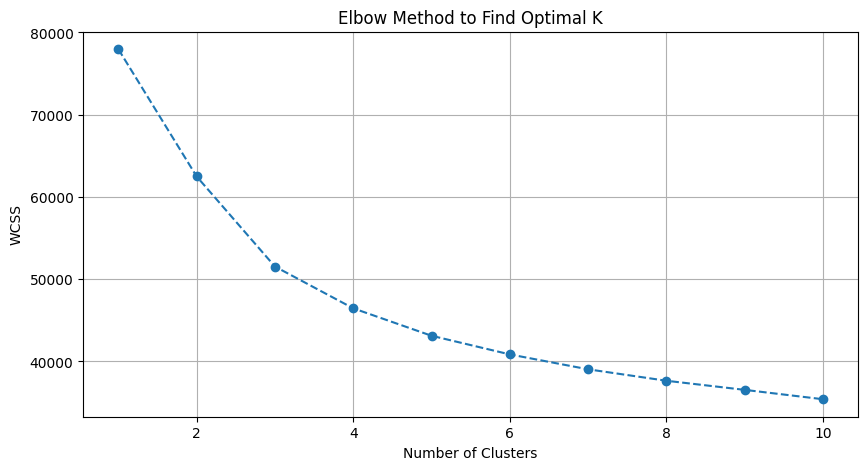

In [116]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

K-Means Clustering

In [117]:
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)


print("Samples per cluster:")
print(df['cluster'].value_counts())

Samples per cluster:
cluster
2    2908
1    1970
0    1619
Name: count, dtype: int64


Visualizing Clusters

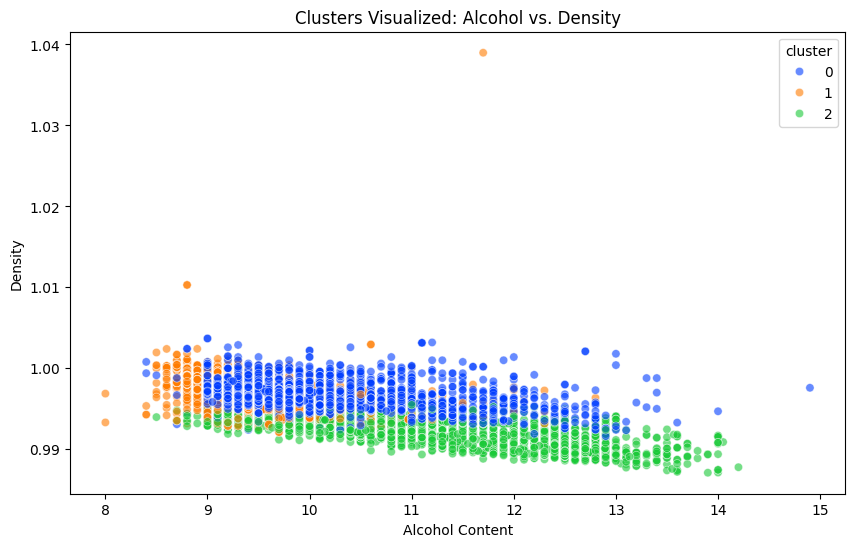

In [118]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='density', hue='cluster', data=df, palette='bright', alpha=0.6)
plt.title('Clusters Visualized: Alcohol vs. Density')
plt.xlabel('Alcohol Content')
plt.ylabel('Density')
plt.show()

Calculate the mean of each feature for each cluster

In [119]:
cluster_means = df.groupby('cluster').mean(numeric_only=True)

print("Manually Calculated Centroids (Average of each cluster):")
display(cluster_means)

Manually Calculated Centroids (Average of each cluster):


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,,
0,0.051266,8.334466,0.532548,0.272187,2.563959,0.088460,15.663372,48.706609,0.996780,3.303935,0.653595,10.325901,5.563928
1,0.997970,6.972386,0.283525,0.355036,10.832716,0.052738,44.859645,169.092893,0.996868,3.157289,0.491756,9.534213,5.552284
2,0.979711,6.756792,0.270313,0.319831,3.395186,0.040214,29.088893,116.926926,0.992065,3.212404,0.489931,11.232874,6.140303


In [120]:
print("\nRed/White Wine distribution across clusters:")
print(pd.crosstab(df['cluster'], df['type']))


Red/White Wine distribution across clusters:
type        0     1
cluster            
0        1536    83
1           4  1966
2          59  2849


Create a dictionary for a new wine

In [121]:
new_wine_data = {
    'fixed acidity': [2.4],
    'volatile acidity': [0.7],
    'citric acid': [0.0],
    'residual sugar': [1.9],
    'chlorides': [0.076],
    'free sulfur dioxide': [11.0],
    'total sulfur dioxide': [34.0],
    'density': [0.9978],
    'pH': [6.51],
    'sulphates': [0.56],
    'alcohol': [9.4],
    'quality': [5]

}

Convert to a DataFrame

In [122]:
new_wine_df = pd.DataFrame(new_wine_data)

Scale the new data using the ALREADY FITTED scaler

In [123]:
new_wine_scaled = scaler.transform(new_wine_df)


Predict the cluster

In [124]:
predicted_cluster = kmeans.predict(new_wine_scaled)

print(f"The new wine belongs to Cluster: {predicted_cluster[0]}")

The new wine belongs to Cluster: 0
